In [17]:
import torch
import torch.nn.functional as F
from torch.autograd import grad
from torchviz import make_dot

In [18]:
torch.__version__

'2.4.1'

In [19]:
# Ranks / Dimension
print(f"Scalar => {torch.tensor(0).dim()}")
print(f"Vector => {torch.tensor([1, 2]).dim()}")
print(f"Matrix => {torch.tensor([[1, 2], [1, 2]]).dim()}")

Scalar => 0
Vector => 1
Matrix => 2


In [20]:
# Data Types
int_tensor = torch.tensor([[1, 2], [1, 2]])
float_tensor = torch.tensor([[1.3, 2.2], [1, 2]])
print(f"Created from python ints {int_tensor.dtype} | {int_tensor}")
print(f"Created from python floats {float_tensor.dtype} | {float_tensor}")
# Change type 
int_tensor_to_float = int_tensor.to(torch.float32)
print(f"Converting int to float {int_tensor_to_float.dtype} | {int_tensor_to_float}")

Created from python ints torch.int64 | tensor([[1, 2],
        [1, 2]])
Created from python floats torch.float32 | tensor([[1.3000, 2.2000],
        [1.0000, 2.0000]])
Converting int to float torch.float32 | tensor([[1., 2.],
        [1., 2.]])


In [21]:
# Common operations 
## create 
t1 = torch.tensor([[2, 3, 4], [4, 5, 6]])

## shape
print(t1.shape)

## reshape or view (LUA/Numpy both conventions)
t1r = t1.reshape(3, 2)
print(t1r)
t1v = t1.view(3, 2)
print(t1v)

## transpose (flipping across diagonals)
print(t1.T)

## matrix multiplication (.matmul or @)
print("matmul", t1.matmul(t1.T))
print("@", t1 @ t1.T)

torch.Size([2, 3])
tensor([[2, 3],
        [4, 4],
        [5, 6]])
tensor([[2, 3],
        [4, 4],
        [5, 6]])
tensor([[2, 4],
        [3, 5],
        [4, 6]])
matmul tensor([[29, 47],
        [47, 77]])
@ tensor([[29, 47],
        [47, 77]])


In [22]:
# Computational Graph

In [23]:
inp = torch.tensor([1.1])
label = torch.tensor([1.0])

W = torch.tensor([2.1], requires_grad=True)
B = torch.tensor([0.0], requires_grad=True)

u = (W @ inp) + B
print("u", u)

a = torch.sigmoid(u)
print("a", a)

loss = F.binary_cross_entropy(a, label)
print("loss", loss)

u tensor([2.3100], grad_fn=<AddBackward0>)
a tensor([0.9097], grad_fn=<SigmoidBackward0>)
loss tensor(0.0946, grad_fn=<BinaryCrossEntropyBackward0>)


In [24]:
grad_L_W = grad(loss, W, retain_graph=True)
grad_L_B = grad(loss, B, retain_graph=True)
print(f"{grad_L_W=}")
print(f"{grad_L_B=}")

grad_L_W=(tensor([-0.0993]),)
grad_L_B=(tensor([-0.0903]),)


In [25]:
loss.backward()

print(W.grad)
print(B.grad)

tensor([-0.0993])
tensor([-0.0903])


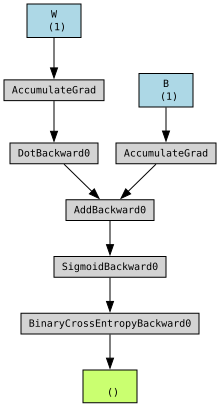

In [26]:
dot = make_dot(loss, params={'W': W, 'B': B, 'inp': inp})
dot

In [27]:
# y = f(x) = x^2

x = torch.tensor([3.0], requires_grad=True)
y = x ** 2
print(y)
y.backward()
print(x.grad)


tensor([9.], grad_fn=<PowBackward0>)
tensor([6.])


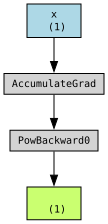

In [28]:
dot = make_dot(y, params={'x': x})
dot

In [29]:
# store and visualize a function's input/output/grads
inps = list(range(-100, 100))
outs, grads = [], []
for i in inps:
    ip = torch.tensor(float(i), requires_grad=True)
    y = ip ** 2
    # y = 2 * ip
    y.backward()
    grads.append(float(ip.grad.item()))
    outs.append(float(y.item()))
    
print(outs)
print(grads)

[10000.0, 9801.0, 9604.0, 9409.0, 9216.0, 9025.0, 8836.0, 8649.0, 8464.0, 8281.0, 8100.0, 7921.0, 7744.0, 7569.0, 7396.0, 7225.0, 7056.0, 6889.0, 6724.0, 6561.0, 6400.0, 6241.0, 6084.0, 5929.0, 5776.0, 5625.0, 5476.0, 5329.0, 5184.0, 5041.0, 4900.0, 4761.0, 4624.0, 4489.0, 4356.0, 4225.0, 4096.0, 3969.0, 3844.0, 3721.0, 3600.0, 3481.0, 3364.0, 3249.0, 3136.0, 3025.0, 2916.0, 2809.0, 2704.0, 2601.0, 2500.0, 2401.0, 2304.0, 2209.0, 2116.0, 2025.0, 1936.0, 1849.0, 1764.0, 1681.0, 1600.0, 1521.0, 1444.0, 1369.0, 1296.0, 1225.0, 1156.0, 1089.0, 1024.0, 961.0, 900.0, 841.0, 784.0, 729.0, 676.0, 625.0, 576.0, 529.0, 484.0, 441.0, 400.0, 361.0, 324.0, 289.0, 256.0, 225.0, 196.0, 169.0, 144.0, 121.0, 100.0, 81.0, 64.0, 49.0, 36.0, 25.0, 16.0, 9.0, 4.0, 1.0, 0.0, 1.0, 4.0, 9.0, 16.0, 25.0, 36.0, 49.0, 64.0, 81.0, 100.0, 121.0, 144.0, 169.0, 196.0, 225.0, 256.0, 289.0, 324.0, 361.0, 400.0, 441.0, 484.0, 529.0, 576.0, 625.0, 676.0, 729.0, 784.0, 841.0, 900.0, 961.0, 1024.0, 1089.0, 1156.0, 1225.0,

In [41]:
# Vectorized version 
inps = list(map(float, range(-100, 100)))
ip = torch.tensor(inps, requires_grad=True)
y = ip ** 2
# create a N dim vector full of 1s to help pytorch get gradients of all of them
y.backward(torch.ones_like(y))
grads = ip.grad.tolist()
outs = y.detach().tolist()


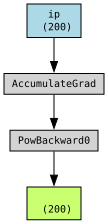

In [42]:
dot = make_dot(y, params={'ip': ip})
dot

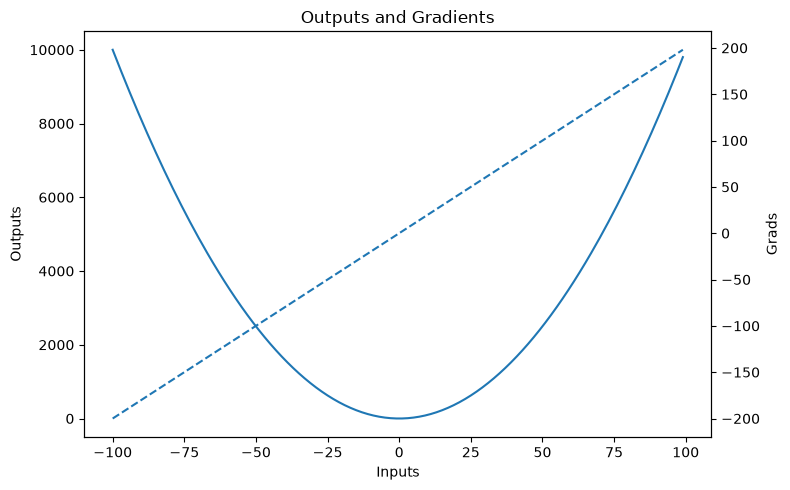

In [40]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

# Left Y-axis — Outputs
ax1.plot(inps, outs, label="Outputs")
ax1.set_xlabel("Inputs")
ax1.set_ylabel("Outputs")
ax1.tick_params(axis="y")

# Right Y-axis — Grads
ax2 = ax1.twinx()
ax2.plot(inps, grads, label="Grads", linestyle="--")
ax2.set_ylabel("Grads")
ax2.tick_params(axis="y")

ax1.set_title("Outputs and Gradients")

plt.tight_layout()
plt.show()